## Introduction to Neural Networks

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

(-0.5, 1.5)

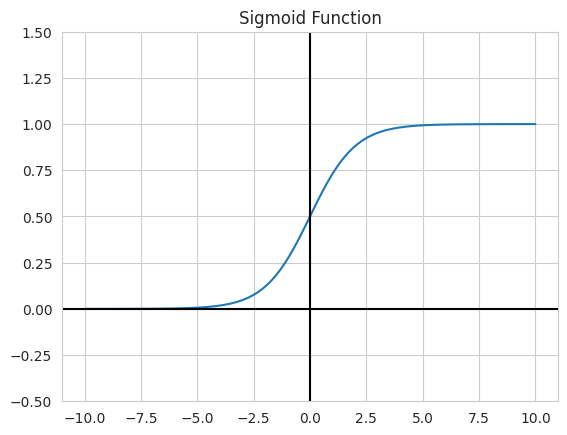

In [29]:
# plot the sigmoid function
values = np.linspace(-10, 10, num=100, dtype=np.float32)
activation = sigmoid(values)
sns.set_style('whitegrid')
plt.title('Sigmoid Function')
plt.plot(values, activation)
plt.axhline(y=0, color='black')
plt.axvline(x=0, color='black')
plt.yticks()
plt.ylim([-0.5, 1.5])

In [30]:
def logic_gate(w1, w2, b):
    return lambda x1, x2: sigmoid(w1 * x1 + w2 * x2 + b)

def test(gate):
    for a, b in (0, 0), (0, 1), (1, 0), (1, 1):
        print(f"{a},{b}: {np.round(gate(a, b))}")

print("OR GATES:")
print("=========")
or_gates = logic_gate(20, 20, -10)
test(or_gates)

OR GATES:
0,0: 0.0
0,1: 1.0
1,0: 1.0
1,1: 1.0


In [31]:
print("AND GATES:")
print("=========")
and_gates = logic_gate(11, 10, -20)
test(and_gates)

AND GATES:
0,0: 0.0
0,1: 0.0
1,0: 0.0
1,1: 1.0


In [32]:
print("NOT GATES:")
print("=========")
not_gates = logic_gate(-20, -20, 10)
test(not_gates)

NOT GATES:
0,0: 1.0
0,1: 0.0
1,0: 0.0
1,1: 0.0


## Exercise 3
Provided below are the following:

- Three weight matrices `W_1`, `W_2` and `W_3` representing the weights in each layer.  The convention for these matrices is that each $W_{i,j}$ gives the weight from neuron $i$ in the previous (left) layer to neuron $j$ in the next (right) layer.  
- A vector `x_in` representing a single input and a matrix `x_mat_in` representing 7 different inputs.
- Two functions: `soft_max_vec` and `soft_max_mat` which apply the soft_max function to a single vector, and row-wise to a matrix.

The goals for this exercise are:
1. For input `x_in` calculate the inputs and outputs to each layer (assuming sigmoid activations for the middle two layers and soft_max output for the final layer.
2. Write a function that does the entire neural network calculation for a single input
3. Write a function that does the entire neural network calculation for a matrix of inputs, where each row is a single input.
4. Test your functions on `x_in` and `x_mat_in`.

This illustrates what happens in a NN during one single forward pass. Roughly speaking, after this forward pass, it remains to compare the output of the network to the known truth values, compute the gradient of the loss function and adjust the weight matrices `W_1`, `W_2` and `W_3` accordingly, and iterate. Hopefully this process will result in better weight matrices and our loss will be smaller afterwards.

In [33]:
W_1 = np.array([[2,-1,1,4],[-1,2,-3,1],[3,-2,-1,5]])
W_2 = np.array([[3,1,-2,1],[-2,4,1,-4],[-1,-3,2,-5],[3,1,1,1]])
W_3 = np.array([[-1,3,-2],[1,-1,-3],[3,-2,2],[1,2,1]])
x_in = np.array([.5,.8,.2])
x_mat_in = np.array([[.5,.8,.2],[.1,.9,.6],[.2,.2,.3],
                     [.6,.1,.9],[.5,.5,.4],[.9,.1,.9],[.1,.8,.7]])

def soft_max_vec(vec):
    return np.exp(vec)/(np.sum(np.exp(vec)))

def soft_max_mat(mat):
    return np.exp(mat)/(np.sum(np.exp(mat),axis=1).reshape(-1,1))

print('the matrix W_1\n')
print(W_1)
print('-'*30)
print('vector input x_in\n')
print(x_in)
print ('-'*30)
print('matrix input x_mat_in -- starts with the vector `x_in`\n')
print(x_mat_in)

the matrix W_1

[[ 2 -1  1  4]
 [-1  2 -3  1]
 [ 3 -2 -1  5]]
------------------------------
vector input x_in

[0.5 0.8 0.2]
------------------------------
matrix input x_mat_in -- starts with the vector `x_in`

[[0.5 0.8 0.2]
 [0.1 0.9 0.6]
 [0.2 0.2 0.3]
 [0.6 0.1 0.9]
 [0.5 0.5 0.4]
 [0.9 0.1 0.9]
 [0.1 0.8 0.7]]


In [34]:
z_2 = np.dot(x_in, W_1)
a_2 = soft_max_vec(z_2)

z_3 = np.dot(a_2, W_2)
a_3 = sigmoid(z_3)

z_4 = np.dot(a_3, W_3)
y_hat = soft_max_vec(z_4)

def nn_comp_vec(x):
    return soft_max_vec(sigmoid(sigmoid(np.dot(x, W_1).dot(W_2).dot(W_3))))

def nn_mat_vec(x):
    return soft_max_mat(sigmoid(sigmoid(np.dot(x, W_1).dot(W_2).dot(W_3))))

In [35]:
nn_comp_vec(x_in)

array([0.35792654, 0.35796174, 0.28411172])

In [36]:
nn_mat_vec(x_mat_in)

array([[0.35792654, 0.35796174, 0.28411172],
       [0.35788774, 0.35798337, 0.28412889],
       [0.30771179, 0.38595692, 0.30633129],
       [0.30675477, 0.38649047, 0.30675477],
       [0.30928141, 0.38508184, 0.30563675],
       [0.30675477, 0.38649047, 0.30675477],
       [0.35412867, 0.36007909, 0.28579224]])